> **Note:** This notebook reuses patterns inspired by the Azure AI Gateway Labs (https://github.com/Azure-Samples/AI-Gateway).

# 🤖 Citadel Agent Frameworks - Testing Center

## Overview

This notebook tests the Citadel Access Contracts using different agent frameworks to simulate multi-turn conversations:

| Access Contract | Agent Framework | Integration Type | Target Model |
|----------------|-----------------|------------------|--------------|
| **Sales-Assistant** | Microsoft Agent Framework | Azure Key Vault (endpoint + key) | gpt-4.1 |
| **HR-ChatAgent** | Microsoft Foundry Agent SDK | Foundry Project Connection | gpt-5.4-mini |
| **Support-Bot** | LangChain | Local (direct endpoint + key) | Mistral-Large-3 |

Each agent will simulate a conversation with a user around the topic of its access contract title.

> **Note:** This notebook assumes you have already deployed your Citadel Governance Hub. If you haven't done so, please refer to the [Citadel Access Contracts Guide](../guides/full-deployment-guide.md) before proceeding.

## Azure Prerequisites

- Citadel Governance Hub deployed with access contracts
- Run `citadel-access-contracts-tests.ipynb` first to create the test contracts
- Python packages: `agent-framework`, `azure-ai-projects`, `langchain`, `langchain-openai` among others (see step 4)
- Have both Azure Key Vault and Foundry target resources provisioned and accessible (permissions and network)

<a id='0'></a>
### 0️⃣ Initialize Notebook Variables

Configure the following variables according to your environment before running the notebook:

In [1]:
# Read environment values from azd
import subprocess, json

def azd_get_value(key):
    """Read a value from the current azd environment."""
    result = subprocess.run(
        ["azd", "env", "get-value", key],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(f"Failed to read {key}: {result.stderr.strip()}")
    return result.stdout.strip()

env_governance_hub_resource_group = azd_get_value("AZURE_RESOURCE_GROUP")
env_location = azd_get_value("AZURE_LOCATION")

env_keyvault_subscription_id = azd_get_value("AZURE_SUBSCRIPTION_ID")
env_keyvault_resource_group  = azd_get_value("SPOKE_RESOURCE_GROUP")
env_keyvault_name            = azd_get_value("SPOKE_KEY_VAULT_NAME")  

env_foundry_subscription_id = azd_get_value("AZURE_SUBSCRIPTION_ID")
env_foundry_resource_group  = azd_get_value("SPOKE_RESOURCE_GROUP")
env_foundry_account_name    = azd_get_value("SPOKE_AI_FOUNDRY_ACCOUNT_NAME")
env_foundry_project_name    = azd_get_value("SPOKE_AI_FOUNDRY_PROJECT_NAME")

print(f"Citadel Hub resource group: {env_governance_hub_resource_group}")
print(f"Location: {env_location}")
print(f"Key Vault: {env_keyvault_name} (Resource Group: {env_keyvault_resource_group}, Subscription: {env_keyvault_subscription_id})")
print(f"Foundry: {env_foundry_account_name} (Project: {env_foundry_project_name}, Resource Group: {env_foundry_resource_group}, Subscription: {env_foundry_subscription_id})")

Citadel Hub resource group: rg-citadel-workshop-bdo
Location: swedencentral
Key Vault: kvcitadelworkshopbdospok (Resource Group: rg-citadel-workshop-bdo-spoke-1, Subscription: e1e1f36c-2153-40f8-b098-a940cb1eb010)
Foundry: aif-citadel-workshop-bdo-spoke-1-e1e1f36c (Project: citadel-agents-project, Resource Group: rg-citadel-workshop-bdo-spoke-1, Subscription: e1e1f36c-2153-40f8-b098-a940cb1eb010)


In [2]:
import os
import sys, json, requests, time
sys.path.insert(1, '../shared')  # add the shared directory to the Python path
import utils
from apimtools import APIMClientTool

# ============================================================================
# 🔧 GOVERNANCE HUB CONFIGURATION (REQUIRED)
# ============================================================================
governance_hub_resource_group = env_governance_hub_resource_group   # Resource group of the deployed Citadel Governance Hub
location = env_location                                             # Azure region (e.g. "swedencentral", "eastus")

# ============================================================================
# 🔧 API VERSION CONFIGURATION
# ============================================================================
inference_api_version = "2024-05-01-preview"
openai_api_version    = "2024-12-01-preview"
targetInferenceApi    = "models"             # 'models' = Universal LLM API | 'openai' = Azure OpenAI API

# ============================================================================
# 🔐 KEY VAULT CONFIGURATION (optional - set use_keyvault_integration = True to enable)
# ============================================================================
use_keyvault_integration = True
keyvault_subscription_id = env_keyvault_subscription_id
keyvault_resource_group  = env_keyvault_resource_group
keyvault_name            = env_keyvault_name

# ============================================================================
# 🤖 MICROSOFT FOUNDRY CONFIGURATION (optional - set use_foundry_integration = True to enable)
# ============================================================================
use_foundry_integration = True
foundry_subscription_id = env_foundry_subscription_id
foundry_resource_group  = env_foundry_resource_group
foundry_account_name    = env_foundry_account_name
foundry_project_name    = env_foundry_project_name
# Foundry connection name created by the access contract.
# Convention: Hub-<BusinessUnit>-<UseCaseName>-<Environment>-<ServiceCode>
# (printed explicitly by citadel-access-contracts-tests.ipynb step 4.2)
# It can also be viewed in the Foundry portal under "Connected Resources" of the project details.
foundry_connection_name = "Hub-HR-ChatAgent-DEV-LLM"

# ============================================================================
# 🧠 PER-AGENT MODEL CONFIGURATION
# ============================================================================
sales_model_name   = "gpt-4.1"          # Sales-Assistant (Microsoft Agent Framework)
hr_model_name      = "gpt-5.4-mini"     # HR-ChatAgent    (Foundry Agent SDK)
support_model_name = "Mistral-Large-3"  # Support-Bot     (LangChain)

# ============================================================================
# 🔁 RETRY CONFIGURATION
# ============================================================================
import asyncio, nest_asyncio
nest_asyncio.apply()

MAX_RETRIES = 2        # Maximum number of retries per call
RETRY_DELAY_BASE = 2   # Base delay in seconds (exponential backoff: base * 2^attempt)

agent_metrics = {
    "MS Agent Framework (Sales)": {"total_tokens": 0, "prompt_tokens": 0, "completion_tokens": 0, "calls": 0, "retries": 0},
    "Foundry SDK (HR)":           {"total_tokens": 0, "prompt_tokens": 0, "completion_tokens": 0, "calls": 0, "retries": 0},
    "LangChain (Support)":        {"total_tokens": 0, "prompt_tokens": 0, "completion_tokens": 0, "calls": 0, "retries": 0},
}


utils.print_ok("Notebook variables initialized!")


✅ Notebook variables initialized! ⌚ 17:51:06.660260 


<a id='1'></a>
### 1️⃣ Verify Azure CLI and Connected Subscription

Ensure Azure CLI is authenticated and connected to the correct subscription:

In [3]:
output = utils.run("az account show", "Retrieved az account", "Failed to get the current az account")

if output.success and output.json_data:
    current_user = output.json_data['user']['name']
    tenant_id = output.json_data['tenantId']
    subscription_id = output.json_data['id']

    utils.print_info(f"Current user: {current_user}")
    utils.print_info(f"Tenant ID: {tenant_id}")
    utils.print_info(f"Subscription ID: {subscription_id}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:51:06.988354 :0s]
👉🏽 Current user: ajakupov@microsoft.com
👉🏽 Tenant ID: 16b3c013-d300-468d-ac64-7eda0820b6d3
👉🏽 Subscription ID: e1e1f36c-2153-40f8-b098-a940cb1eb010


<a id='2'></a>
### 2️⃣ Initialize APIM Client Tool

👉 An existing Citadel Governance Hub deployment is expected. Initialize the APIM client to interact with your deployment:

In [4]:
try:
    apimClientTool = APIMClientTool(governance_hub_resource_group)
    apimClientTool.initialize()
    apimClientTool.discover_api(targetInferenceApi)

    apim_resource_gateway_url = str(apimClientTool.apim_resource_gateway_url)
    azure_endpoint = str(apimClientTool.azure_endpoint)
    
    # Get supported models
    supported_models = apimClientTool.get_policy_fragment_supported_models("set-backend-pools")
    utils.print_info(f"Supported models: {supported_models}")

    if targetInferenceApi == "openai":
        chat_completions_url = f"{azure_endpoint}openai/deployments/{{model_name}}/chat/completions?api-version={inference_api_version}"
    else:
        chat_completions_url = f"{azure_endpoint}models/chat/completions?api-version={inference_api_version}"
    
    utils.print_info(f"Chat Completion Endpoint: {chat_completions_url}")
    utils.print_ok(f"APIM Client initialized!")
except Exception as e:
    utils.print_error(f"Error initializing APIM Client: {e}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:51:07.332458 :0s]
👉🏽 Current user: ajakupov@microsoft.com
👉🏽 Tenant ID: 16b3c013-d300-468d-ac64-7eda0820b6d3
👉🏽 Subscription ID: e1e1f36c-2153-40f8-b098-a940cb1eb010
⚙️ Running: az resource list -g rg-citadel-workshop-bdo --resource-type Microsoft.ApiManagement/service 
✅ Listing APIM Resources ⌚ 17:51:09.194948 :1s]
👉🏽 APIM Service Id: /subscriptions/e1e1f36c-2153-40f8-b098-a940cb1eb010/resourceGroups/rg-citadel-workshop-bdo/providers/Microsoft.ApiManagement/service/apim-kmx3r4ewzwgog
👉🏽 APIM Gateway URL: https://apim-kmx3r4ewzwgog.azure-api.net
👉🏽 Retrieved key 0 for subscription: master
👉🏽 Retrieved key 1 for subscription: LLM-Testing-UniversalLLMAllModels-DEV-SUB-01
👉🏽 Retrieved key 2 for subscription: LLM-Sales-Assistant-DEV-SUB-01
👉🏽 Retrieved key 3 for subscription: LLM-HR-ChatAgent-DEV-SUB-01
👉🏽 Retrieved key 4 for subscription: LLM-Support-Bot-DEV-SUB-01
👉🏽 Found API with id /subscriptions/e1e1f36c-2153-40f8-b098-a940cb1

<a id='3'></a>
### 3️⃣ Retrieve Access Contract API Keys

Get the API keys for each access contract to test with different agent frameworks.

In [5]:
# Define the access contracts to test (matching those from citadel-access-contracts-tests.ipynb)
access_contract_configs = [
    {
        "name": "Sales-Assistant",
        "business_unit": "Sales",
        "use_case_name": "Assistant",
        "environment": "DEV",
        "agent_framework": "Microsoft Agent Framework",
        "endpoint_secret": "SALES-LLM-ENDPOINT",  # Key Vault secret names from access contract
        "apikey_secret": "SALES-LLM-KEY",
        "description": "Sales Assistant - Helps with sales inquiries, product information, and pricing"
    },
    {
        "name": "HR-ChatAgent",
        "business_unit": "HR",
        "use_case_name": "ChatAgent",
        "environment": "DEV",
        "agent_framework": "Foundry SDK",
        "foundry_connection": foundry_connection_name,  # Foundry connection created by access contract
        "description": "HR Chat Agent - Assists with HR policies, benefits, and employee questions"
    },
    {
        "name": "Support-Bot",
        "business_unit": "Support",
        "use_case_name": "Bot",
        "environment": "DEV",
        "agent_framework": "LangChain",
        "description": "Support Bot - Provides technical support and troubleshooting assistance"
    }
]

# Map contracts to their subscription keys
contract_keys = {}

for config in access_contract_configs:
    product_id = f"LLM-{config['business_unit']}-{config['use_case_name']}-{config['environment']}"
    subscription_name = f"{product_id}-SUB-01"
    
    for sub in apimClientTool.apim_subscriptions:
        if subscription_name.lower() in sub.get('name', '').lower():
            contract_keys[config['name']] = {
                "key": sub.get('key'),
                "product_id": product_id,
                "agent_framework": config['agent_framework'],
                "description": config['description'],
                "config": config  # Store full config for later use
            }
            utils.print_ok(f"Found key for {config['name']} ({config['agent_framework']})")
            break
    else:
        utils.print_warning(f"No key found for {config['name']} - run citadel-access-contracts-tests.ipynb first")

utils.print_info(f"\nRetrieved keys for {len(contract_keys)} access contracts")

✅ Found key for Sales-Assistant (Microsoft Agent Framework) ⌚ 17:51:14.700323 
✅ Found key for HR-ChatAgent (Foundry SDK) ⌚ 17:51:14.700528 
✅ Found key for Support-Bot (LangChain) ⌚ 17:51:14.700551 
👉🏽 
Retrieved keys for 3 access contracts


<a id='4'></a>
### 4️⃣ Install Required Agent Frameworks

Install the necessary Python packages for each agent framework.

> **Tip:** Set `install_agent_frameworks = False` at the top of the cell below to skip installation on repeated runs (verification still executes so you can confirm package availability).

In [6]:
# Install and verify agent framework packages in the ACTIVE notebook kernel
# ---------------------------------------------------------------------------
# Toggle: set to False to skip package installation on repeated notebook runs
# (e.g. once the kernel already has the required packages installed). The
# verification step at the end always runs so you still see the active versions.
install_agent_frameworks = False
# ---------------------------------------------------------------------------

import sys
import importlib
import importlib.metadata as md

utils.print_info(f"Python executable in use: {sys.executable}")

if install_agent_frameworks:
    utils.print_info("Upgrading packaging tools in this kernel...")
    %pip install -q --upgrade pip setuptools wheel

    # Avoid the agent-framework meta package here. It pulls optional wheels that
    # currently overwrite agent_framework/__init__.py in this environment.
    utils.print_info("Installing Microsoft Agent Framework core packages...")
    %pip install -q -U "agent-framework-core>=1.2.0" "agent-framework-openai>=1.2.0"

    packages = [
        "azure-ai-projects>=2.0.0b4",                      # Microsoft Foundry Agent SDK (PromptAgentDefinition support)
        "openai>=1.0.0",                                   # OpenAI-compatible client used by Foundry sample pattern
        "langchain>=0.2.0",                                # LangChain
        "langchain-openai>=0.1.0",                         # LangChain OpenAI integration
        "azure-identity",                                  # Azure authentication
        "azure-keyvault-secrets",                          # Azure Key Vault for Sales-Assistant
        "nest-asyncio",                                    # For running async in Jupyter
        "pywin32",                                         # For Windows users to avoid event loop issues
        "matplotlib>=3.9"                                  # For visualizations (>=3.9 required for matplotlib.backends.registry)
    ]

    utils.print_info("Installing/upgrading remaining dependencies...")
    for package in packages:
        try:
            %pip install -q --upgrade {package}
            utils.print_ok(f"Installed/updated {package}")
        except Exception as e:
            utils.print_warning(f"Could not install {package}: {e}")

    # Validate semantic-conventions compatibility; fallback pin only if required attrs are missing
    try:
        semconv_module = importlib.import_module("opentelemetry.semconv_ai")
        SpanAttributes = getattr(semconv_module, "SpanAttributes")
        has_llm_system = hasattr(SpanAttributes, "LLM_SYSTEM")
        has_llm_request_max_tokens = hasattr(SpanAttributes, "LLM_REQUEST_MAX_TOKENS")
        utils.print_info(
            f"Pre-check SpanAttributes compatibility: LLM_SYSTEM={has_llm_system}, "
            f"LLM_REQUEST_MAX_TOKENS={has_llm_request_max_tokens}"
        )

        if not (has_llm_system and has_llm_request_max_tokens):
            utils.print_warning(
                "Detected incompatible opentelemetry semantic conventions for current agent-framework build. "
                "Applying fallback pin: opentelemetry-semantic-conventions-ai==0.4.13"
            )
            %pip install -q --upgrade --force-reinstall "opentelemetry-semantic-conventions-ai==0.4.13"
            utils.print_ok("Pinned opentelemetry-semantic-conventions-ai==0.4.13")
    except Exception as e:
        utils.print_warning(f"Could not pre-check SpanAttributes compatibility: {e}")
else:
    utils.print_info("Skipping agent framework installation (install_agent_frameworks=False). Verifying existing packages only.")

# Verify versions and runtime availability from the same interpreter
utils.print_info("\nVerifying installed package versions in current kernel...")
for pkg in [
    "agent-framework-core",
    "agent-framework-openai",
    "opentelemetry-semantic-conventions-ai",
    "azure-ai-projects",
    "azure-identity",
    "openai",
    "langchain",
    "langchain-openai",
    "matplotlib",
]:
    try:
        version = md.version(pkg)
        utils.print_ok(f"{pkg}: {version}")
    except Exception:
        utils.print_warning(f"{pkg}: not found")

try:
    agent_framework_module = importlib.import_module("agent_framework")
    utils.print_ok(f"agent_framework.__version__ available: {hasattr(agent_framework_module, '__version__')}")
except Exception as e:
    utils.print_warning(f"Could not validate agent_framework package import: {e}")

try:
    semconv_module = importlib.import_module("opentelemetry.semconv_ai")
    SpanAttributes = getattr(semconv_module, "SpanAttributes")
    utils.print_ok(f"SpanAttributes.LLM_SYSTEM available: {hasattr(SpanAttributes, 'LLM_SYSTEM')}")
    utils.print_ok(f"SpanAttributes.LLM_REQUEST_MAX_TOKENS available: {hasattr(SpanAttributes, 'LLM_REQUEST_MAX_TOKENS')}")
except Exception as e:
    utils.print_warning(f"Could not validate opentelemetry.semconv_ai SpanAttributes: {e}")

try:
    models_module = importlib.import_module("azure.ai.projects.models")
    PromptAgentDefinition = getattr(models_module, "PromptAgentDefinition")
    utils.print_ok(f"PromptAgentDefinition is available: {PromptAgentDefinition}")
except Exception as e:
    utils.print_error(f"PromptAgentDefinition is NOT available in active kernel: {e}")
    utils.print_info("If this fails, restart the kernel, then re-run cells 1 to 4 before running Foundry cells.")

utils.print_ok("Package installation and verification complete!")

👉🏽 Python executable in use: /Users/alibekjakupov/Documents/current/citadel/ai-hub-gateway-solution-accelerator/workshop/.venv/bin/python
👉🏽 Skipping agent framework installation (install_agent_frameworks=False). Verifying existing packages only.
👉🏽 
Verifying installed package versions in current kernel...
✅ agent-framework-core: 1.3.0 ⌚ 17:51:14.739361 
✅ agent-framework-openai: 1.2.0 ⌚ 17:51:14.749400 
✅ opentelemetry-semantic-conventions-ai: 0.5.1 ⌚ 17:51:14.755547 
✅ azure-ai-projects: 2.1.0 ⌚ 17:51:14.768305 
✅ azure-identity: 1.25.3 ⌚ 17:51:14.776473 
✅ openai: 2.32.0 ⌚ 17:51:14.784627 
✅ langchain: 1.2.15 ⌚ 17:51:14.795097 
✅ langchain-openai: 1.2.1 ⌚ 17:51:14.804721 
✅ matplotlib: 3.10.9 ⌚ 17:51:14.814017 


<frozen abc>:106: ExperimentalWarning: [HARNESS] MemoryStore is experimental and may change or be removed in future versions without notice.
<frozen abc>:106: ExperimentalWarning: [SKILLS] SkillResource is experimental and may change or be removed in future versions without notice.


✅ agent_framework.__version__ available: True ⌚ 17:51:15.576549 
✅ SpanAttributes.LLM_SYSTEM available: True ⌚ 17:51:15.581880 
✅ SpanAttributes.LLM_REQUEST_MAX_TOKENS available: True ⌚ 17:51:15.581897 
✅ PromptAgentDefinition is available: <class 'azure.ai.projects.models._models.PromptAgentDefinition'> ⌚ 17:51:20.262298 
✅ Package installation and verification complete! ⌚ 17:51:20.262457 


---
## 🧠 Agent Framework Implementations
---

<a id='5'></a>
### 5️⃣ Microsoft Agent Framework (Sales-Assistant)

Create a Sales Assistant agent using **Microsoft Agent Framework**.
This agent retrieves its endpoint and API key from **Azure Key Vault** based on the access contract parameters.

> **Key Vault Secrets:**
> - `SALES-LLM-ENDPOINT`: The LLM endpoint URL
> - `SALES-LLM-KEY`: The API key for authentication

In [7]:
from azure.identity import DefaultAzureCredential
from azure.keyvault.secrets import SecretClient
from datetime import datetime

class MSAgentFrameworkSalesAgent:
    """Sales Assistant Agent using Microsoft Agent Framework with Azure Key Vault integration.
    
    Uses OpenAIChatClient.as_agent configured with custom headers to work with 
    Azure API Management gateways that expect the 'api-key' header.
    """
    
    def __init__(self, keyvault_name: str, endpoint_secret_name: str, apikey_secret_name: str, model_name: str):
        self.keyvault_name = keyvault_name
        self.endpoint_secret_name = endpoint_secret_name
        self.apikey_secret_name = apikey_secret_name
        self.model_name = model_name
        self.conversation_history = []
        self.total_tokens = 0
        self.prompt_tokens = 0
        self.completion_tokens = 0
        self.calls = 0
        self.retries = 0
        self.agent = None
        self.session = None  # AgentSession for multi-turn conversation context
        
        # Retrieve endpoint and API key from Azure Key Vault
        self._init_from_keyvault()
        
        # System prompt for Sales Assistant
        self.system_prompt = f"""You are a Sales Assistant AI agent. Your role is to:
- Answer questions about products and services
- Provide pricing information and discounts
- Help customers find the right solutions for their needs
- Handle sales inquiries professionally and helpfully

Be concise, professional, and always try to guide customers toward a purchase decision.
Current date: {datetime.now().strftime("%Y-%m-%d")}"""
        
        # Initialize Microsoft Agent Framework agent
        self._init_agent()
    
    def _init_from_keyvault(self):
        """Retrieve endpoint and API key from Azure Key Vault."""
        try:
            credential = DefaultAzureCredential()
            keyvault_uri = f"https://{self.keyvault_name}.vault.azure.net"
            client = SecretClient(vault_url=keyvault_uri, credential=credential)
            
            # Get endpoint from Key Vault
            endpoint_secret = client.get_secret(self.endpoint_secret_name)
            self.endpoint = endpoint_secret.value
            utils.print_ok(f"Retrieved endpoint: ({self.endpoint}) from Key Vault secret: {self.endpoint_secret_name}")
            
            # Get API key from Key Vault
            apikey_secret = client.get_secret(self.apikey_secret_name)
            self.api_key = apikey_secret.value
            utils.print_ok(f"Retrieved API key ({self.api_key[:4]}****) from Key Vault secret: {self.apikey_secret_name}")
            
        except Exception as e:
            utils.print_error(f"Failed to retrieve secrets from Key Vault: {e}")
            raise
    
    def _init_agent(self):
        """Initialize the Microsoft Agent Framework agent using OpenAIChatClient.as_agent.
        
        Uses OpenAIChatClient with custom default_headers to send 'api-key' header
        that Azure API Management expects, while using standard OpenAI URL patterns.
        """
        try:
            # Compatibility shim for agent-framework + opentelemetry-semconv-ai drift
            from opentelemetry.semconv_ai import SpanAttributes

            compatibility_mappings = {
                "LLM_SYSTEM": ["GEN_AI_SYSTEM"],
                "LLM_REQUEST_MAX_TOKENS": ["LLM_MAX_NEW_TOKENS", "GEN_AI_MAX_TOKENS"],
                "LLM_REQUEST_TEMPERATURE": ["LLM_TEMPERATURE", "GEN_AI_TEMPERATURE"],
                "LLM_REQUEST_TOP_P": ["LLM_TOP_P", "GEN_AI_TOP_P"],
                "LLM_REQUEST_MODEL": ["LLM_MODEL_NAME", "GEN_AI_REQUEST_MODEL"],
                "LLM_RESPONSE_MODEL": ["LLM_MODEL_NAME", "GEN_AI_RESPONSE_MODEL"],
                "LLM_TOKEN_TYPE": ["GEN_AI_TOKEN_TYPE"],
            }

            for legacy_attr, candidates in compatibility_mappings.items():
                if not hasattr(SpanAttributes, legacy_attr):
                    mapped = False
                    for candidate in candidates:
                        if hasattr(SpanAttributes, candidate):
                            setattr(SpanAttributes, legacy_attr, getattr(SpanAttributes, candidate))
                            mapped = True
                            break
                    if not mapped:
                        fallback_key = legacy_attr.lower().replace("_", ".")
                        setattr(SpanAttributes, legacy_attr, fallback_key)

            utils.print_info(
                "SpanAttributes compatibility:"
                f" LLM_SYSTEM={hasattr(SpanAttributes, 'LLM_SYSTEM')},"
                f" LLM_REQUEST_MAX_TOKENS={hasattr(SpanAttributes, 'LLM_REQUEST_MAX_TOKENS')},"
                f" LLM_REQUEST_TEMPERATURE={hasattr(SpanAttributes, 'LLM_REQUEST_TEMPERATURE')},"
                f" LLM_REQUEST_TOP_P={hasattr(SpanAttributes, 'LLM_REQUEST_TOP_P')},"
                f" LLM_REQUEST_MODEL={hasattr(SpanAttributes, 'LLM_REQUEST_MODEL')}"
            )
            
            from agent_framework._sessions import AgentSession
            from agent_framework.openai import OpenAIChatClient
            
            # Create OpenAI Chat Client with custom headers for APIM authentication
            chat_client = OpenAIChatClient(
                base_url=self.endpoint,
                api_key="placeholder",
                model=self.model_name,
                default_headers={
                    "api-key": self.api_key
                }
            )
            
            # Latest API shape in installed pre-release: create agent via chat client
            self.agent = chat_client.as_agent(
                name="SalesAssistant",
                instructions=self.system_prompt,
            )
            
            # Create a persistent session for multi-turn conversations
            self.session = AgentSession()
            
            utils.print_ok("Microsoft Agent Framework agent initialized successfully (using OpenAIChatClient.as_agent + AgentSession)")
            
        except ImportError as e:
            error_msg = (
                f"❌ Failed to import Microsoft Agent Framework: {e}\n"
                "  → Restart the kernel and re-run cells 1 to 5\n"
                "  → If you reinstall packages, use agent-framework-core and agent-framework-openai only\n"
                "  → Avoid the agent-framework meta package in this notebook environment"
            )
            utils.print_error(error_msg)
            raise RuntimeError(error_msg) from e
        except Exception as e:
            error_msg = (
                f"❌ Failed to initialize Microsoft Agent Framework agent: {e}\n"
                "  → Verify the endpoint from Key Vault is correct and accessible\n"
                "  → Verify the API key from Key Vault is valid\n"
                "  → Check that the APIM gateway is running and the subscription is active\n"
                f"  → Endpoint: {self.endpoint}\n"
                f"  → Model: {self.model_name}"
            )
            utils.print_error(error_msg)
            raise RuntimeError(error_msg) from e
    
    async def chat_async(self, user_message: str) -> str:
        """Send a message and get a response using Microsoft Agent Framework with retry logic."""
        self.conversation_history.append({"role": "user", "content": user_message})
        
        last_error = None
        for attempt in range(MAX_RETRIES + 1):
            try:
                # Use Microsoft Agent Framework with persistent session for conversation context
                result = await self.agent.run(user_message, session=self.session)
                content = result.text if hasattr(result, 'text') else str(result)
                
                # Track metrics (Microsoft Agent Framework may not expose token counts directly)
                estimated_tokens = len(content.split()) * 1.3  # rough estimate
                self.completion_tokens += int(estimated_tokens)
                self.prompt_tokens += len(user_message.split())
                self.total_tokens = self.prompt_tokens + self.completion_tokens
                self.calls += 1
                
                if attempt > 0:
                    utils.print_info(f"  ✅ Succeeded after {attempt} retry(ies)")
                
                self.conversation_history.append({"role": "assistant", "content": content})
                return content
                
            except Exception as e:
                last_error = e
                if attempt < MAX_RETRIES:
                    self.retries += 1
                    delay = RETRY_DELAY_BASE * (2 ** attempt)
                    utils.print_warning(f"  ⚠️ Attempt {attempt + 1}/{MAX_RETRIES + 1} failed: {e}")
                    utils.print_info(f"  ⏳ Retrying in {delay}s...")
                    await asyncio.sleep(delay)
                else:
                    error_msg = (
                        f"❌ Microsoft Agent Framework call failed after {MAX_RETRIES + 1} attempts.\n"
                        f"  Last error: {last_error}\n"
                        f"  → Check that the APIM gateway is healthy and not throttling requests\n"
                        f"  → Verify the Sales-Assistant access contract rate limits\n"
                        f"  → Ensure the model '{self.model_name}' is available in the backend pool\n"
                        f"  → Endpoint: {self.endpoint}"
                    )
                    utils.print_error(error_msg)
                    self.conversation_history.append({"role": "assistant", "content": f"[ERROR] {error_msg}"})
                    return f"[ERROR] {error_msg}"
    
    def chat(self, user_message: str) -> str:
        """Synchronous wrapper for chat_async."""
        return asyncio.get_event_loop().run_until_complete(self.chat_async(user_message))
    
    def get_metrics(self) -> dict:
        """Return token usage metrics including retries."""
        return {
            "total_tokens": self.total_tokens,
            "prompt_tokens": self.prompt_tokens,
            "completion_tokens": self.completion_tokens,
            "calls": self.calls,
            "retries": self.retries
        }

utils.print_ok("Microsoft Agent Framework Sales Agent class defined (using OpenAIChatClient.as_agent + AgentSession)!")

✅ Microsoft Agent Framework Sales Agent class defined (using OpenAIChatClient.as_agent + AgentSession)! ⌚ 17:51:20.426703 


In [8]:
# Test the Microsoft Agent Framework Sales Agent with Key Vault integration
if "Sales-Assistant" in contract_keys:
    config = contract_keys["Sales-Assistant"]["config"]
    
    utils.print_info("🤖 Starting Microsoft Agent Framework Sales Agent conversation...")
    utils.print_info("="*60)
    utils.print_info(f"📌 Access Contract: {config['description']}")
    utils.print_info(f"📌 Model: {sales_model_name}")
    utils.print_info(f"📦 Retrieving credentials from Azure Key Vault: {keyvault_name}")
    
    try:
        sales_agent = MSAgentFrameworkSalesAgent(
            keyvault_name=keyvault_name,
            endpoint_secret_name=config.get("endpoint_secret", "SALES-LLM-ENDPOINT"),
            apikey_secret_name=config.get("apikey_secret", "SALES-LLM-KEY"),
            model_name=sales_model_name
        )
        
        # Simulate a sales conversation
        sales_conversation = [
            "Hi, I'm looking for an enterprise AI solution for my company.",
            "What features do you offer for data analytics?",
            "How much does the enterprise plan cost?",
            "Do you offer any discounts for annual subscriptions?",
            "Can you help me set up a demo?"
        ]
        
        for i, user_msg in enumerate(sales_conversation, 1):
            print(f"\n👤 User ({i}/{len(sales_conversation)}): {user_msg}")
            response = sales_agent.chat(user_msg)
            print(f"🤖 Sales Agent: {response[:300]}{'...' if len(response) > 300 else ''}")
            time.sleep(1)  # Rate limiting
        
        # Store metrics
        agent_metrics["MS Agent Framework (Sales)"] = sales_agent.get_metrics()
        utils.print_ok(f"\n📊 Sales Agent Metrics: {agent_metrics['MS Agent Framework (Sales)']}")
        
    except Exception as e:
        utils.print_error(f"Failed to initialize Sales Agent: {e}")
        utils.print_info("Make sure Key Vault secrets are configured and you have access permissions.")
else:
    utils.print_warning("Sales-Assistant contract not found. Skipping Microsoft Agent Framework test.")

👉🏽 🤖 Starting Microsoft Agent Framework Sales Agent conversation...
👉🏽 ============================================================
👉🏽 📌 Access Contract: Sales Assistant - Helps with sales inquiries, product information, and pricing
👉🏽 📌 Model: gpt-4.1
👉🏽 📦 Retrieving credentials from Azure Key Vault: kvcitadelworkshopbdospok
❌ Failed to retrieve secrets from Key Vault: (Forbidden) Public network access is disabled and request is not from a trusted service nor via an approved private link.
Caller: appid=04b07795-8ddb-461a-bbee-02f9e1bf7b46;oid=2ffc3578-cf60-462a-8a11-645fe0771606;iss=https://sts.windows.net/16b3c013-d300-468d-ac64-7eda0820b6d3/
Vault: kvcitadelworkshopbdospok;location=swedencentral
Code: Forbidden
Message: Public network access is disabled and request is not from a trusted service nor via an approved private link.
Caller: appid=04b07795-8ddb-461a-bbee-02f9e1bf7b46;oid=2ffc3578-cf60-462a-8a11-645fe0771606;iss=https://sts.windows.net/16b3c013-d300-468d-ac64-7eda0820b6d3/

<a id='6'></a>
### 6️⃣ Microsoft Foundry Agent SDK (HR-ChatAgent)

Create an HR Chat Agent using the **Microsoft Foundry Agent SDK** with the official **Prompt Agent** pattern.

> **Foundry Integration (based on official sample):**
> - Uses `PromptAgentDefinition` to create a versioned agent
> - Uses `conversations` API for multi-turn dialogue
> - Uses `responses` API to get agent responses
> - Deployment pattern: `connection_name/model_name` routes through Citadel
> - Authenticates using Azure DefaultAzureCredential
>
> **Reference:** [sample_agent_basic.py](https://github.com/Azure/azure-sdk-for-python/blob/main/sdk/ai/azure-ai-projects/samples/agents/sample_agent_basic.py)

In [9]:
from azure.identity import DefaultAzureCredential
from datetime import datetime

class FoundryHRAgent:
    """HR Chat Agent using Microsoft Foundry Agent SDK with Prompt Agent pattern.
    
    Uses the Azure AI Projects SDK following the official sample pattern:
    - Creates a versioned Prompt Agent using PromptAgentDefinition
    - Uses conversations API for multi-turn dialogue
    - Uses responses API for agent responses
    - Uses get_openai_client() as context manager per the official SDK pattern
    
    Based on: https://github.com/Azure/azure-sdk-for-python/blob/main/sdk/ai/azure-ai-projects/samples/agents/sample_agent_basic.py
    """
    
    def __init__(self, foundry_account_name: str, foundry_project_name: str, 
                 connection_name: str, model_name: str):
        self.foundry_account_name = foundry_account_name
        self.foundry_project_name = foundry_project_name
        self.connection_name = connection_name
        self.model_name = model_name
        
        # Deployment name pattern: connection_name/model_name
        # This routes through the Foundry connection to Citadel governance hub
        self.deployment_name = f"{connection_name}/{model_name}"
        
        # Metrics tracking
        self.total_tokens = 0
        self.prompt_tokens = 0
        self.completion_tokens = 0
        self.calls = 0
        self.retries = 0
        
        # SDK clients and agent references
        self.credential = None
        self.project_client = None
        self.agent = None
        self.conversation_id = None  # Track conversation ID for multi-turn
        
        # System prompt for HR Assistant
        self.system_prompt = f"""You are an HR Chat Agent AI assistant. Your role is to:
- Answer questions about company HR policies
- Explain employee benefits and compensation packages
- Help with onboarding and offboarding procedures
- Provide guidance on workplace conduct and compliance
- Assist with leave requests and time-off policies

Be empathetic, professional, and ensure you protect employee privacy.
Always recommend consulting with HR directly for sensitive matters.
Current date: {datetime.now().strftime("%Y-%m-%d")}"""
        
        # Initialize Foundry client and create agent
        self._init_foundry_client()
    
    def _init_foundry_client(self):
        """Initialize Azure AI Foundry project client and create Prompt Agent."""
        try:
            from azure.ai.projects import AIProjectClient
            from azure.ai.projects.models import PromptAgentDefinition
            
            # Build the endpoint for the Foundry project
            # Format: https://{account}.services.ai.azure.com/api/projects/{project}
            endpoint = f"https://{self.foundry_account_name}.services.ai.azure.com/api/projects/{self.foundry_project_name}"
            
            utils.print_info(f"Connecting to Foundry endpoint: {endpoint}")
            
            # Create credential and project client
            self.credential = DefaultAzureCredential()
            self.project_client = AIProjectClient(
                endpoint=endpoint,
                credential=self.credential
            )
            utils.print_ok(f"Foundry project client initialized for: {self.foundry_project_name}")
            
            # Create a versioned Prompt Agent using the official pattern
            self.agent = self.project_client.agents.create_version(
                agent_name="HR-ChatAgent",
                definition=PromptAgentDefinition(
                    model=self.deployment_name,  # connection_name/model_name routes through Citadel
                    instructions=self.system_prompt,
                ),
            )
            utils.print_ok(f"Agent created (id: {self.agent.id}, name: {self.agent.name}, version: {self.agent.version})")
            utils.print_info(f"Using deployment: {self.deployment_name}")
            
        except ImportError as e:
            error_msg = (
                f"❌ Import error - SDK version may not support Agents API: {e}\n"
                "  → Fix: install from this kernel with: %pip install --upgrade \"azure-ai-projects>=2.0.0b4\"\n"
                "  → Then restart kernel and re-run setup cells to refresh imports"
            )
            utils.print_error(error_msg)
            raise RuntimeError(error_msg) from e
        except Exception as e:
            error_msg = (
                f"❌ Failed to initialize Foundry agent: {e}\n"
                f"  → Verify the Foundry account name: {self.foundry_account_name}\n"
                f"  → Verify the Foundry project name: {self.foundry_project_name}\n"
                f"  → Ensure the Foundry connection '{self.connection_name}' was created by the access contract\n"
                f"  → Check that DefaultAzureCredential has access to the Foundry project\n"
                f"  → Run 'az login' and ensure the correct subscription is selected"
            )
            utils.print_error(error_msg)
            raise RuntimeError(error_msg) from e
    
    def chat(self, user_message: str) -> str:
        """Send a message and get a response using Foundry Agents SDK with retry logic.
        
        Uses the conversations and responses API pattern from the official sample.
        Uses get_openai_client() as a context manager per the SDK pattern.
        """
        last_error = None
        for attempt in range(MAX_RETRIES + 1):
            try:
                return self._chat_with_agent(user_message)
            except Exception as e:
                last_error = e
                if attempt < MAX_RETRIES:
                    self.retries += 1
                    delay = RETRY_DELAY_BASE * (2 ** attempt)
                    utils.print_warning(f"  ⚠️ Attempt {attempt + 1}/{MAX_RETRIES + 1} failed: {e}")
                    utils.print_info(f"  ⏳ Retrying in {delay}s...")
                    time.sleep(delay)
                else:
                    error_msg = (
                        f"❌ Foundry Agent call failed after {MAX_RETRIES + 1} attempts.\n"
                        f"  Last error: {last_error}\n"
                        f"  → Check that the Foundry project '{self.foundry_project_name}' is accessible\n"
                        f"  → Verify the connection '{self.connection_name}' routes correctly to Citadel\n"
                        f"  → Ensure the model '{self.model_name}' is available via the connection\n"
                        f"  → Check the HR-ChatAgent access contract rate limits and quotas\n"
                        f"  → Deployment: {self.deployment_name}"
                    )
                    utils.print_error(error_msg)
                    return f"[ERROR] {error_msg}"
    
    def _chat_with_agent(self, user_message: str) -> str:
        """Chat using the Prompt Agent with conversations and responses API.
        
        Uses get_openai_client() as context manager, matching the official SDK sample.
        """
        with self.project_client.get_openai_client() as openai_client:
            if self.conversation_id is None:
                # Create a new conversation with the first user message
                conversation = openai_client.conversations.create(
                    items=[{"type": "message", "role": "user", "content": user_message}],
                )
                self.conversation_id = conversation.id
                utils.print_info(f"Created conversation (id: {self.conversation_id})")
            else:
                # Add user message to existing conversation
                openai_client.conversations.items.create(
                    conversation_id=self.conversation_id,
                    items=[{"type": "message", "role": "user", "content": user_message}],
                )
            
            # Get response from the agent (official sample uses 'agent_reference')
            response = openai_client.responses.create(
                conversation=self.conversation_id,
                extra_body={"agent_reference": {"name": self.agent.name, "type": "agent_reference"}},
            )
            
            content = response.output_text if hasattr(response, 'output_text') else str(response)
            
            # Track metrics - estimate tokens since responses API may not return usage
            estimated_prompt_tokens = len(user_message.split())
            estimated_completion_tokens = int(len(content.split()) * 1.3)
            self.prompt_tokens += estimated_prompt_tokens
            self.completion_tokens += estimated_completion_tokens
            self.total_tokens = self.prompt_tokens + self.completion_tokens
            self.calls += 1
            
            return content
    
    def get_metrics(self) -> dict:
        """Return token usage metrics including retries."""
        return {
            "total_tokens": self.total_tokens,
            "prompt_tokens": self.prompt_tokens,
            "completion_tokens": self.completion_tokens,
            "calls": self.calls,
            "retries": self.retries
        }
    
    def close(self, delete_version: bool = False):
        """Clean up resources.
        
        Args:
            delete_version: If True, deletes the agent version from Foundry. Default is False.
        """
        if delete_version:
            try:
                if self.agent and self.project_client:
                    self.project_client.agents.delete_version(
                        agent_name=self.agent.name,
                        agent_version=self.agent.version
                    )
                    utils.print_ok(f"Agent version deleted (name: {self.agent.name}, version: {self.agent.version})")
            except Exception as e:
                utils.print_warning(f"Failed to delete agent version: {e}")
        else:
            if self.agent:
                utils.print_info(f"Agent version retained (name: {self.agent.name}, version: {self.agent.version}). Pass delete_version=True to remove it.")

utils.print_ok("Foundry HR Agent class defined (aligned with sample Prompt Agent pattern)!")

✅ Foundry HR Agent class defined (aligned with sample Prompt Agent pattern)! ⌚ 17:51:21.993437 


In [10]:
# Test the Foundry SDK HR Agent with project connection
if "HR-ChatAgent" in contract_keys:
    config = contract_keys["HR-ChatAgent"]["config"]
    
    utils.print_info("🏢 Starting Microsoft Foundry SDK HR Agent conversation...")
    utils.print_info("="*60)
    utils.print_info(f"📦 Connecting to Foundry project: {foundry_project_name}")
    utils.print_info(f"🔗 Using connection: {config.get('foundry_connection', foundry_connection_name)}")
    utils.print_info(f"📌 Access Contract: {config['description']}")
    utils.print_info(f"📌 Model: {hr_model_name}")
    
    try:
        hr_agent = FoundryHRAgent(
            foundry_account_name=foundry_account_name,
            foundry_project_name=foundry_project_name,
            connection_name=config.get("foundry_connection", foundry_connection_name),
            model_name=hr_model_name
        )
        
        # Simulate an HR conversation
        hr_conversation = [
            "Hello, I'm a new employee. Can you tell me about the benefits package?",
            "What is the vacation policy? How many days do I get?",
            "How do I request time off for a medical appointment?",
            "What's the process for reporting workplace issues?",
            "Thank you for your help! One more question - when is the next open enrollment period?"
        ]
        
        for i, user_msg in enumerate(hr_conversation, 1):
            print(f"\n👤 User ({i}/{len(hr_conversation)}): {user_msg}")
            response = hr_agent.chat(user_msg)
            print(f"🤖 HR Agent: {response[:300]}{'...' if len(response) > 300 else ''}")
            time.sleep(1)  # Rate limiting
        
        # Store metrics
        agent_metrics["Foundry SDK (HR)"] = hr_agent.get_metrics()
        utils.print_ok(f"\n📊 HR Agent Metrics: {agent_metrics['Foundry SDK (HR)']}")
        
        # Clean up (set delete_version=True to remove the agent version from Foundry)
        hr_agent.close(delete_version=False)
        
    except Exception as e:
        utils.print_error(f"Failed to initialize HR Agent: {e}")
        utils.print_info("Make sure the Foundry connection is created by the access contract deployment.")
else:
    utils.print_warning("HR-ChatAgent contract not found. Skipping Foundry SDK test.")

👉🏽 🏢 Starting Microsoft Foundry SDK HR Agent conversation...
👉🏽 ============================================================
👉🏽 📦 Connecting to Foundry project: citadel-agents-project
👉🏽 🔗 Using connection: Hub-HR-ChatAgent-DEV-LLM
👉🏽 📌 Access Contract: HR Chat Agent - Assists with HR policies, benefits, and employee questions
👉🏽 📌 Model: gpt-5.4-mini
👉🏽 Connecting to Foundry endpoint: https://aif-citadel-workshop-bdo-spoke-1-e1e1f36c.services.ai.azure.com/api/projects/citadel-agents-project
✅ Foundry project client initialized for: citadel-agents-project ⌚ 17:51:21.999309 
✅ Agent created (id: HR-ChatAgent:1, name: HR-ChatAgent, version: 1) ⌚ 17:51:35.933939 
👉🏽 Using deployment: Hub-HR-ChatAgent-DEV-LLM/gpt-5.4-mini

👤 User (1/5): Hello, I'm a new employee. Can you tell me about the benefits package?
👉🏽 Created conversation (id: conv_0d7940855cc50efa003UbNI3NfjBSjKSoBJCNzclsDwnK1Ijre)
🤖 HR Agent: Welcome aboard! I can help with that.

I don’t have your company’s specific benefits det

<a id='7'></a>
### 7️⃣ LangChain Agent (Support-Bot)

Create a Support Bot agent using the **LangChain** framework.
This is a local agent that uses variables for the LLM endpoint, key, and model name.

> **Local Configuration:**
> - Endpoint: Retrieved from APIM client
> - API Key: Retrieved from APIM subscription
> - Model: Specified in request body

In [11]:
from datetime import datetime

class LangChainSupportAgent:
    """Support Bot Agent using LangChain framework with local configuration."""
    
    def __init__(self, llm_endpoint: str, api_key: str, model_name: str):
        """
        Initialize LangChain Support Agent with direct endpoint configuration.
        
        Args:
            llm_endpoint: The LLM API endpoint URL
            api_key: The API key for authentication
            model_name: The model name to include in request body
        """
        self.llm_endpoint = llm_endpoint
        self.api_key = api_key
        self.model_name = model_name
        self.messages = []
        self.total_tokens = 0
        self.prompt_tokens = 0
        self.completion_tokens = 0
        self.calls = 0
        self.retries = 0
        
        # System prompt for Support Bot
        self.system_prompt = f"""You are a Technical Support Bot AI assistant. Your role is to:
- Help users troubleshoot technical issues
- Provide step-by-step guidance for common problems
- Explain technical concepts in simple terms
- Escalate complex issues to human support when needed
- Log and track support tickets

Be patient, thorough, and always verify that the user's issue is resolved.
Ask clarifying questions when needed to diagnose problems accurately.
Current date: {datetime.now().strftime("%Y-%m-%d")}"""
        
        self.messages.append({"role": "system", "content": self.system_prompt})
        
        utils.print_ok(f"LangChain Support Agent initialized")
        utils.print_info(f"Endpoint: {self.llm_endpoint}")
        utils.print_info(f"Model: {self.model_name}")
    
    def chat(self, user_message: str) -> str:
        """
        Send a message and get a response using LangChain patterns with retry logic.
        Uses direct API calls with endpoint, key, and model in body.
        """
        self.messages.append({"role": "user", "content": user_message})
        
        # LangChain-style payload with model in body
        payload = {
            "model": self.model_name,  # Model name in body as per LangChain pattern
            "messages": self.messages,
            "max_tokens": 500,
            "temperature": 0.7
        }
        
        last_error = None
        for attempt in range(MAX_RETRIES + 1):
            try:
                # Direct API call using configured endpoint and key
                response = requests.post(
                    self.llm_endpoint,
                    headers={
                        "api-key": self.api_key,
                        "Content-Type": "application/json"
                    },
                    json=payload,
                    timeout=60
                )
                
                if response.status_code == 200:
                    data = response.json()
                    content = data.get("choices", [{}])[0].get("message", {}).get("content", "")
                    
                    # Track token usage
                    usage = data.get("usage", {})
                    self.total_tokens += usage.get("total_tokens", 0)
                    self.prompt_tokens += usage.get("prompt_tokens", 0)
                    self.completion_tokens += usage.get("completion_tokens", 0)
                    self.calls += 1
                    
                    if attempt > 0:
                        utils.print_info(f"  ✅ Succeeded after {attempt} retry(ies)")
                    
                    self.messages.append({"role": "assistant", "content": content})
                    return content
                elif response.status_code == 429:
                    # Rate limited — retry with backoff
                    retry_after = int(response.headers.get("Retry-After", RETRY_DELAY_BASE * (2 ** attempt)))
                    raise Exception(f"Rate limited (429). Retry-After: {retry_after}s. Body: {response.text[:200]}")
                else:
                    raise Exception(f"HTTP {response.status_code}: {response.text[:200]}")
                    
            except Exception as e:
                last_error = e
                if attempt < MAX_RETRIES:
                    self.retries += 1
                    delay = RETRY_DELAY_BASE * (2 ** attempt)
                    utils.print_warning(f"  ⚠️ Attempt {attempt + 1}/{MAX_RETRIES + 1} failed: {e}")
                    utils.print_info(f"  ⏳ Retrying in {delay}s...")
                    time.sleep(delay)
                else:
                    error_msg = (
                        f"❌ LangChain Support Agent call failed after {MAX_RETRIES + 1} attempts.\n"
                        f"  Last error: {last_error}\n"
                        f"  → Check that the APIM gateway is healthy and not throttling\n"
                        f"  → Verify the Support-Bot access contract rate limits and quotas\n"
                        f"  → Ensure the model '{self.model_name}' is available in the backend pool\n"
                        f"  → Endpoint: {self.llm_endpoint}"
                    )
                    utils.print_error(error_msg)
                    # Remove the user message that failed so conversation stays consistent
                    self.messages.pop()
                    return f"[ERROR] {error_msg}"
    
    def get_metrics(self) -> dict:
        """Return token usage metrics including retries."""
        return {
            "total_tokens": self.total_tokens,
            "prompt_tokens": self.prompt_tokens,
            "completion_tokens": self.completion_tokens,
            "calls": self.calls,
            "retries": self.retries
        }

utils.print_ok("LangChain Support Agent class defined!")

✅ LangChain Support Agent class defined! ⌚ 17:52:01.075167 


In [12]:
# Test the LangChain Support Agent with local configuration
if "Support-Bot" in contract_keys:
    support_key = contract_keys["Support-Bot"]["key"]
    
    utils.print_info("🦜 Starting LangChain Support Agent conversation...")
    utils.print_info("="*60)
    utils.print_info(f"📦 Using local configuration with APIM endpoint")
    utils.print_info(f"📌 Access Contract: {contract_keys['Support-Bot']['config']['description']}")
    utils.print_info(f"📌 Model: {support_model_name}")
    
    try:
        support_agent = LangChainSupportAgent(
            llm_endpoint=chat_completions_url,  # Local endpoint variable
            api_key=support_key,                 # Local API key variable
            model_name=support_model_name        # Model name in body
        )
        
        # Simulate a support conversation
        support_conversation = [
            "Hi, I'm having trouble connecting to the VPN. It keeps timing out.",
            "I'm using Windows 11 and the company VPN client version 3.2.",
            "I've tried restarting but the issue persists. What else can I try?",
            "The network adapter shows it's connected but no internet access through VPN.",
            "That worked! The DNS settings were incorrect. Thank you for your help!"
        ]
        
        for i, user_msg in enumerate(support_conversation, 1):
            print(f"\n👤 User ({i}/{len(support_conversation)}): {user_msg}")
            response = support_agent.chat(user_msg)
            print(f"🤖 Support Agent: {response[:300]}{'...' if len(response) > 300 else ''}")
            time.sleep(1)  # Rate limiting
        
        # Store metrics
        agent_metrics["LangChain (Support)"] = support_agent.get_metrics()
        utils.print_ok(f"\n📊 Support Agent Metrics: {agent_metrics['LangChain (Support)']}")
        
    except Exception as e:
        utils.print_error(f"Failed to initialize Support Agent: {e}")
else:
    utils.print_warning("Support-Bot contract not found. Skipping LangChain test.")

👉🏽 🦜 Starting LangChain Support Agent conversation...
👉🏽 ============================================================
👉🏽 📦 Using local configuration with APIM endpoint
👉🏽 📌 Access Contract: Support Bot - Provides technical support and troubleshooting assistance
👉🏽 📌 Model: Mistral-Large-3
✅ LangChain Support Agent initialized ⌚ 17:52:01.082941 
👉🏽 Endpoint: https://apim-kmx3r4ewzwgog.azure-api.net/models/chat/completions?api-version=2024-05-01-preview
👉🏽 Model: Mistral-Large-3

👤 User (1/5): Hi, I'm having trouble connecting to the VPN. It keeps timing out.
🤖 Support Agent: I'm sorry to hear you're having trouble with your VPN connection. Let's troubleshoot this step by step. To help me diagnose the issue more accurately, could you please provide:

1. Which VPN service/client are you using? (e.g., Cisco AnyConnect, NordVPN, company VPN, etc.)
2. What device and operati...

👤 User (2/5): I'm using Windows 11 and the company VPN client version 3.2.
🤖 Support Agent: Thank you for the deta

---
## 📊 Agent Performance Comparison
---

<a id='8'></a>
### 8️⃣ Display Agent Statistics and Comparison

Visualize token consumption across all agent frameworks using pie charts.


📊 AGENT FRAMEWORKS PERFORMANCE SUMMARY
Agent Framework                Calls    Retries    Prompt       Completion   Total       
------------------------------------------------------------------------------------------
Foundry SDK (HR)               5        0          57           791          848         
LangChain (Support)            5        0          5326         2091         7417        
------------------------------------------------------------------------------------------
TOTAL                                   0                                    8265        


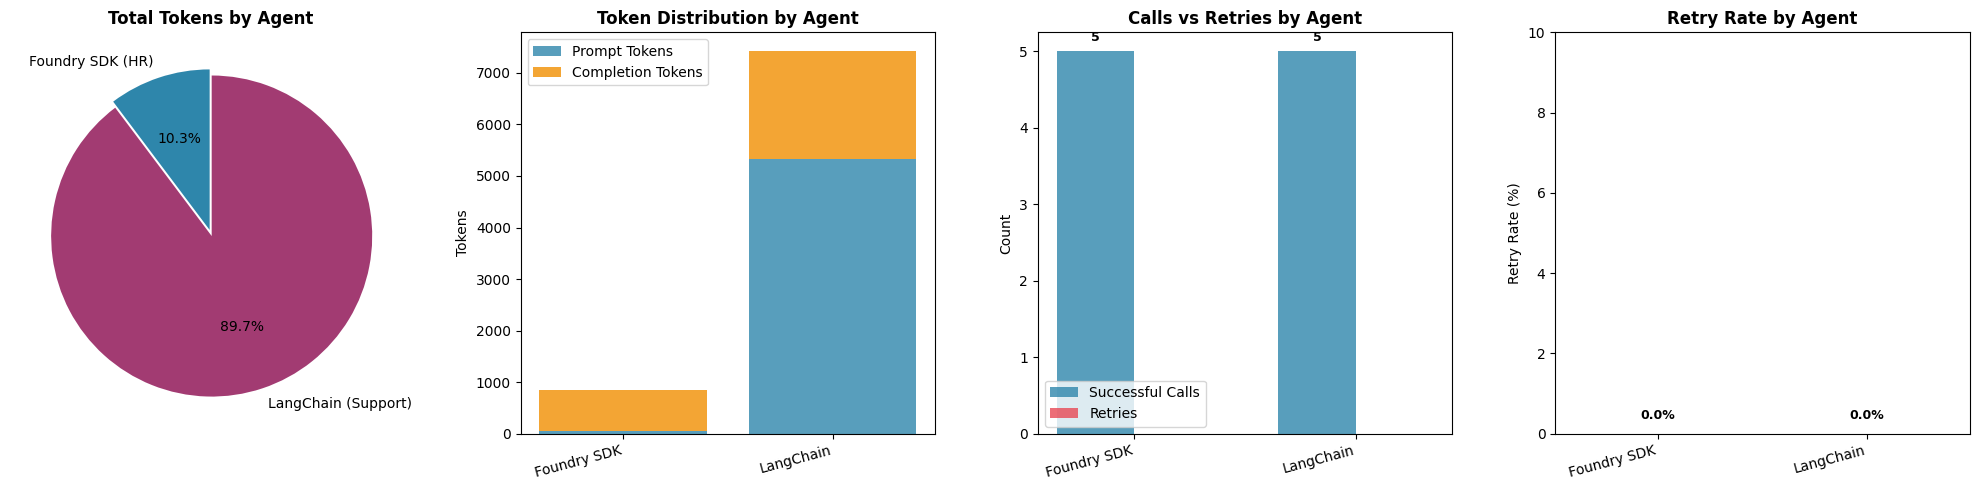

✅ Visualization saved to 'agent_metrics_comparison.png' ⌚ 17:52:58.022510 


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Filter agents with data
active_agents = {k: v for k, v in agent_metrics.items() if v.get('total_tokens', 0) > 0}

if active_agents:
    # Print summary table
    print("\n" + "="*90)
    print("📊 AGENT FRAMEWORKS PERFORMANCE SUMMARY")
    print("="*90)
    print(f"{'Agent Framework':<30} {'Calls':<8} {'Retries':<10} {'Prompt':<12} {'Completion':<12} {'Total':<12}")
    print("-"*90)
    
    total_all_tokens = 0
    total_all_retries = 0
    for agent_name, metrics in active_agents.items():
        retries = metrics.get('retries', 0)
        print(f"{agent_name:<30} {metrics['calls']:<8} {retries:<10} {metrics['prompt_tokens']:<12} {metrics['completion_tokens']:<12} {metrics['total_tokens']:<12}")
        total_all_tokens += metrics['total_tokens']
        total_all_retries += retries
    
    print("-"*90)
    print(f"{'TOTAL':<30} {'':<8} {total_all_retries:<10} {'':<12} {'':<12} {total_all_tokens:<12}")
    print("="*90)
    
    # Create visualization
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Color scheme
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    # 1. Total Tokens Pie Chart
    labels = list(active_agents.keys())
    total_tokens = [m['total_tokens'] for m in active_agents.values()]
    
    axes[0].pie(total_tokens, labels=labels, autopct='%1.1f%%', colors=colors[:len(labels)], 
                startangle=90, explode=[0.02]*len(labels))
    axes[0].set_title('Total Tokens by Agent', fontsize=12, fontweight='bold')
    
    # 2. Prompt vs Completion Tokens (Stacked Bar)
    x = np.arange(len(labels))
    prompt_tokens = [m['prompt_tokens'] for m in active_agents.values()]
    completion_tokens = [m['completion_tokens'] for m in active_agents.values()]
    
    axes[1].bar(x, prompt_tokens, label='Prompt Tokens', color='#2E86AB', alpha=0.8)
    axes[1].bar(x, completion_tokens, bottom=prompt_tokens, label='Completion Tokens', color='#F18F01', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([l.split('(')[0].strip() for l in labels], rotation=15, ha='right')
    axes[1].set_ylabel('Tokens')
    axes[1].set_title('Token Distribution by Agent', fontsize=12, fontweight='bold')
    axes[1].legend()
    
    # 3. API Calls vs Retries (Grouped Bar)
    calls = [m['calls'] for m in active_agents.values()]
    retries = [m.get('retries', 0) for m in active_agents.values()]
    
    bar_width = 0.35
    axes[2].bar(x - bar_width/2, calls, bar_width, label='Successful Calls', color='#2E86AB', alpha=0.8)
    axes[2].bar(x + bar_width/2, retries, bar_width, label='Retries', color='#E84855', alpha=0.8)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([l.split('(')[0].strip() for l in labels], rotation=15, ha='right')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Calls vs Retries by Agent', fontsize=12, fontweight='bold')
    axes[2].legend()
    
    # Add value labels on bars
    for i, (call, retry) in enumerate(zip(calls, retries)):
        axes[2].text(i - bar_width/2, call + 0.1, str(call), ha='center', va='bottom', fontweight='bold', fontsize=9)
        if retry > 0:
            axes[2].text(i + bar_width/2, retry + 0.1, str(retry), ha='center', va='bottom', fontweight='bold', fontsize=9, color='#E84855')
    
    # 4. Retry Rate (% of total attempts that were retries)
    retry_rates = []
    for m in active_agents.values():
        total_attempts = m['calls'] + m.get('retries', 0)
        rate = (m.get('retries', 0) / total_attempts * 100) if total_attempts > 0 else 0
        retry_rates.append(rate)
    
    bar_colors = ['#4CAF50' if r == 0 else '#FF9800' if r < 30 else '#E84855' for r in retry_rates]
    bars = axes[3].bar(x, retry_rates, color=bar_colors, alpha=0.8)
    axes[3].set_xticks(x)
    axes[3].set_xticklabels([l.split('(')[0].strip() for l in labels], rotation=15, ha='right')
    axes[3].set_ylabel('Retry Rate (%)')
    axes[3].set_title('Retry Rate by Agent', fontsize=12, fontweight='bold')
    axes[3].set_ylim(0, max(max(retry_rates) * 1.3, 10))
    
    # Add value labels
    for bar, rate in zip(bars, retry_rates):
        axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                     f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('agent_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    utils.print_ok("Visualization saved to 'agent_metrics_comparison.png'")
else:
    utils.print_warning("No agent metrics available. Run the agent tests first.")

<a id='9'></a>
### 9️⃣ Token Efficiency Analysis

Analyze the token efficiency (completion tokens per call) for each agent.


📈 TOKEN EFFICIENCY & RELIABILITY ANALYSIS
Agent Framework                Avg Total    Avg Prompt   Avg Compl.   Efficiency   Retries    Reliability 
-----------------------------------------------------------------------------------------------
Foundry SDK (HR)               169.6        11.4         158.2        93.3       % 0          100.0      %
LangChain (Support)            1483.4       1065.2       418.2        28.2       % 0          100.0      %

💡 Efficiency = (Completion Tokens / Total Tokens) × 100
   Higher efficiency means more output for less input (context)
🔄 Reliability = (Successful Calls / Total Attempts) × 100
   Higher reliability means fewer retries needed


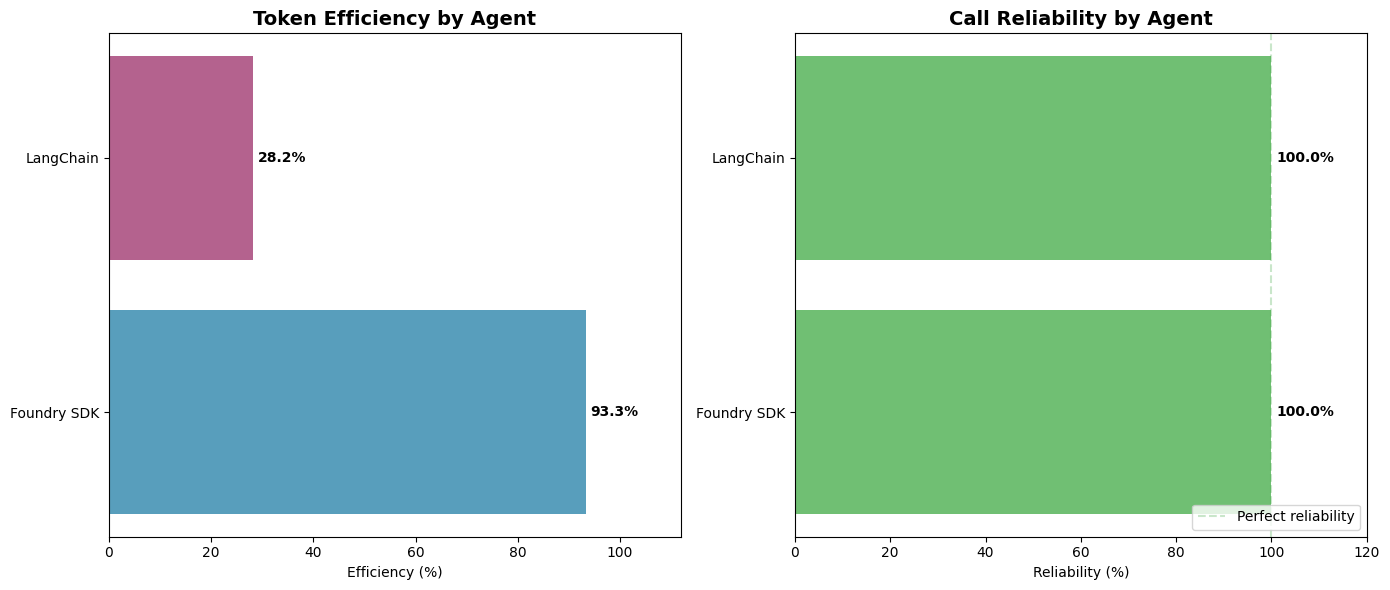

In [14]:
import matplotlib.pyplot as plt
import numpy as np

active_agents = {k: v for k, v in agent_metrics.items() if v.get('total_tokens', 0) > 0}

if active_agents:
    # Calculate efficiency metrics
    efficiency_data = []
    for agent_name, metrics in active_agents.items():
        calls = metrics['calls']
        retries = metrics.get('retries', 0)
        if calls > 0:
            avg_total = metrics['total_tokens'] / calls
            avg_prompt = metrics['prompt_tokens'] / calls
            avg_completion = metrics['completion_tokens'] / calls
            efficiency = metrics['completion_tokens'] / metrics['total_tokens'] * 100 if metrics['total_tokens'] > 0 else 0
            total_attempts = calls + retries
            reliability = (calls / total_attempts * 100) if total_attempts > 0 else 100.0
            
            efficiency_data.append({
                'name': agent_name,
                'avg_total': avg_total,
                'avg_prompt': avg_prompt,
                'avg_completion': avg_completion,
                'efficiency': efficiency,
                'retries': retries,
                'reliability': reliability
            })
    
    # Print efficiency table
    print("\n" + "="*95)
    print("📈 TOKEN EFFICIENCY & RELIABILITY ANALYSIS")
    print("="*95)
    print(f"{'Agent Framework':<30} {'Avg Total':<12} {'Avg Prompt':<12} {'Avg Compl.':<12} {'Efficiency':<12} {'Retries':<10} {'Reliability':<12}")
    print("-"*95)
    
    for data in efficiency_data:
        print(f"{data['name']:<30} {data['avg_total']:<12.1f} {data['avg_prompt']:<12.1f} {data['avg_completion']:<12.1f} {data['efficiency']:<11.1f}% {data['retries']:<10} {data['reliability']:<11.1f}%")
    
    print("="*95)
    print("\n💡 Efficiency = (Completion Tokens / Total Tokens) × 100")
    print("   Higher efficiency means more output for less input (context)")
    print("🔄 Reliability = (Successful Calls / Total Attempts) × 100")
    print("   Higher reliability means fewer retries needed")
    
    # Create side-by-side visualization: Efficiency vs Reliability
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    labels = [d['name'].split('(')[0].strip() for d in efficiency_data]
    efficiencies = [d['efficiency'] for d in efficiency_data]
    reliabilities = [d['reliability'] for d in efficiency_data]
    retries_list = [d['retries'] for d in efficiency_data]
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    # Left: Token Efficiency
    bars1 = ax1.barh(labels, efficiencies, color=colors[:len(labels)], alpha=0.8)
    for bar, eff in zip(bars1, efficiencies):
        ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{eff:.1f}%', va='center', fontweight='bold')
    ax1.set_xlabel('Efficiency (%)')
    ax1.set_title('Token Efficiency by Agent', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, max(efficiencies) * 1.2)
    
    # Right: Reliability (with retry count annotation)
    reliability_colors = ['#4CAF50' if r == 100 else '#FF9800' if r > 80 else '#E84855' for r in reliabilities]
    bars2 = ax2.barh(labels, reliabilities, color=reliability_colors, alpha=0.8)
    for bar, rel, retries in zip(bars2, reliabilities, retries_list):
        label = f'{rel:.1f}%'
        if retries > 0:
            label += f' ({retries} retries)'
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                label, va='center', fontweight='bold')
    ax2.set_xlabel('Reliability (%)')
    ax2.set_title('Call Reliability by Agent', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 120)
    ax2.axvline(x=100, color='#4CAF50', linestyle='--', alpha=0.3, label='Perfect reliability')
    ax2.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
else:
    utils.print_warning("No agent metrics available for efficiency analysis.")

---
## 📊 Results Summary
---

This notebook tested the following access contracts with different agent frameworks:

| Access Contract | Agent Framework | Use Case | Integration | Target Model |
|----------------|-----------------|----------|-------------|--------------|
| Sales-Assistant | Microsoft Agent Framework | Sales inquiries & pricing | Azure Key Vault (endpoint + key) | gpt-4.1 |
| HR-ChatAgent | Microsoft Foundry Agent SDK | HR policies & benefits | Foundry Project Connection | gpt-4.1 |
| Support-Bot | LangChain | Technical support | Local (direct endpoint + key) | phi-4 |

Each agent simulated a multi-turn conversation relevant to its business domain.
The metrics collected help compare token consumption across different frameworks.

**Integration Patterns:**
- **Microsoft Agent Framework (Sales)**: Retrieves endpoint and API key from Azure Key Vault secrets, uses `AzureOpenAIChatClient.as_agent()`
- **Foundry SDK (HR)**: Uses `connection_name/model_name` deployment pattern via Foundry project
- **LangChain (Support)**: Local configuration with endpoint, key, and model in request body

In [15]:
# Final summary
utils.print_info("\n" + "="*60)
utils.print_info("🎉 AGENT FRAMEWORKS TESTING COMPLETE!")
utils.print_info("="*60)

total_retries = 0
for agent_name, metrics in agent_metrics.items():
    retries = metrics.get('retries', 0)
    total_retries += retries
    if metrics.get('total_tokens', 0) > 0:
        retry_info = f", {retries} retries" if retries > 0 else ""
        utils.print_ok(f"✅ {agent_name}: {metrics['total_tokens']} total tokens, {metrics['calls']} calls{retry_info}")
    else:
        utils.print_warning(f"⚠️ {agent_name}: No data (contract may not be deployed)")

if total_retries > 0:
    utils.print_warning(f"\n🔄 Total retries across all agents: {total_retries}")
    utils.print_info("  Consider reviewing rate limits or backend pool capacity if retries are high")

utils.print_info("\n📌 Next Steps:")
utils.print_info("  1. Review token consumption patterns and retry rates")
utils.print_info("  2. Adjust rate limits in access contracts if retries are frequent")
utils.print_info("  3. Implement production-ready error handling")
utils.print_info("  4. Add monitoring and alerting for each agent type")

👉🏽 
👉🏽 🎉 AGENT FRAMEWORKS TESTING COMPLETE!
👉🏽 ============================================================
⚠️ ⚠️ MS Agent Framework (Sales): No data (contract may not be deployed) ⌚ 17:52:58.090985 
✅ ✅ Foundry SDK (HR): 848 total tokens, 5 calls ⌚ 17:52:58.090997 
✅ ✅ LangChain (Support): 7417 total tokens, 5 calls ⌚ 17:52:58.091003 
👉🏽 
📌 Next Steps:
👉🏽   1. Review token consumption patterns and retry rates
👉🏽   2. Adjust rate limits in access contracts if retries are frequent
👉🏽   3. Implement production-ready error handling
👉🏽   4. Add monitoring and alerting for each agent type


<a id='cleanup'></a>
### 🧹 Cleanup (Optional)

The access contracts and APIM resources used by this notebook are managed by `citadel-access-contracts-tests.ipynb`.
Run the cleanup cell in that notebook to remove the test access contracts.

> **Note:** This notebook does not create any APIM resources directly. The Foundry agent versions created during testing can be deleted via the Foundry portal if needed.